<p>
<h1><b><center></center></b></h1>
</p>
<h1><b><center>Space Flight Dynamics</center></b></h1>
<h2><b><center>Prof. Jorge I. Zuluaga</center></b></h1>
<h2><b><center>Assignment 4</center></b><h2>
<h3><b><center>Interplanetary Mission</center></b><h3>
<h5><center><b>Assigned</b>: May 14, 2025</center><h5>
<h5><center><b>Due</b>: June 2, 2025</center><h5>

<hr/>
<b>Name</b>: Naireth Farak Román
<br/>
<b>ID number</b>: 1102812285
<br/>


## Problem Statement

We will determine the launch window for a mission to one of the planets in the Solar System. To do this, choose a planet according to the last digit of your ID number: 0 and 5, Mercury; 1 and 6, Venus; 2 and 7, Mars; 3 and 8, Jupiter; 4 and 9, Saturn. Uranus and Neptune are too far away for this exercise.

To choose the launch window, we will build what is known as a *porkchop diagram* (see an example below), which will allow us to identify the optimal departure date (the one requiring the least fuel).

These diagrams show contours of the value of the parameter $C_3 = v_\infty^2$ (the change in velocity that must be applied to the spacecraft to leave Earth and travel to the planet), as a function of the departure date from Earth and the arrival date at the planet. The best launch date is the one for which $C_3$ is minimum.

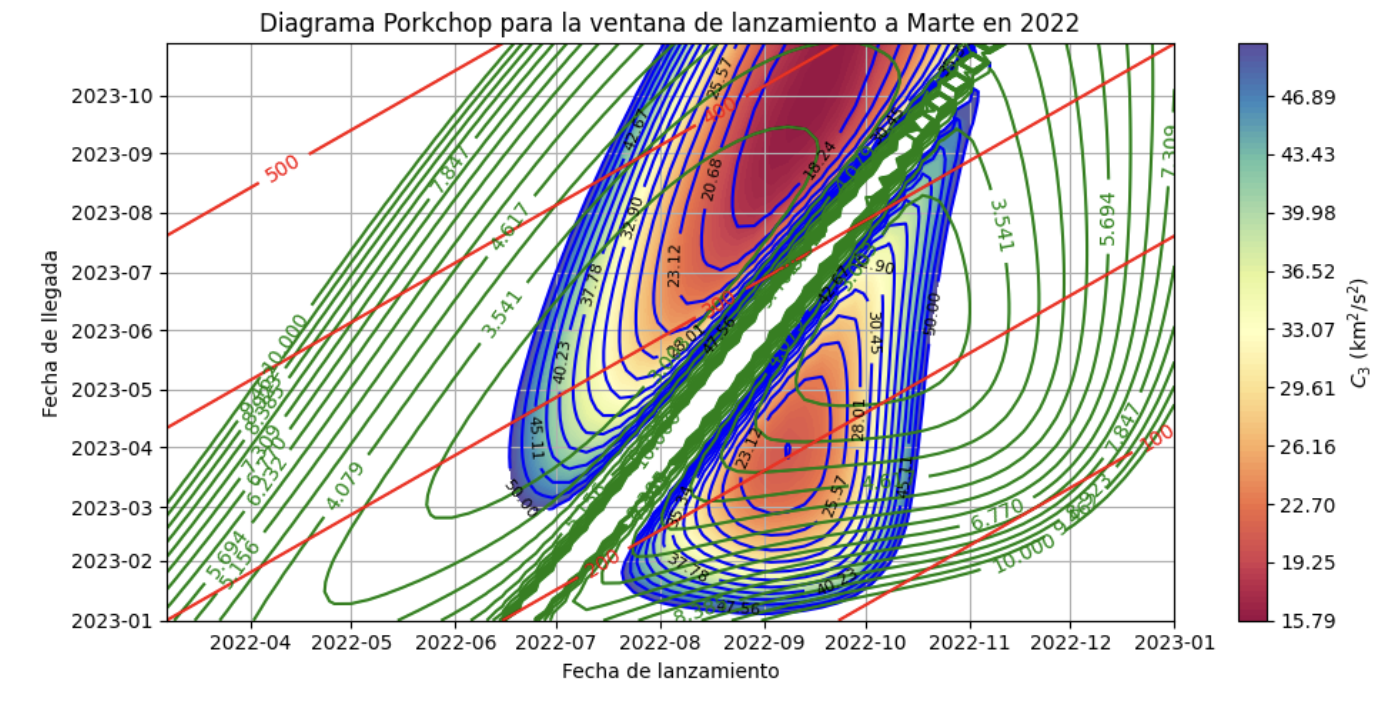

**Optional**: If the mission is designed so that, during its *flyby*, the spacecraft approaches the planet to a distance $q$ at which scientific data can be collected, or even inserted into a circumplanetary orbit, the flyby orbit properties can be calculated with the data from this problem. Using the properties of the hyperbolic orbit, show that the eccentricity of the *flyby* orbit around the planet is:

$$
e = 1 + \frac{v_\infty^2}{\mu/q}
$$

Calculate the flyby-orbit eccentricity assuming that $q = 5 R_p$ and determine the orbit angles $\beta$ and $\delta$. Could you draw the vehicle's *flyby* orbit around the planet, with angles and distances to scale?

## Guidance

The procedure is not trivial, but once completed you will see that it is not too difficult either. If you want to work through it in stages, you can follow some or all of these steps:

1. Take the date on which you begin this assignment. This will be our reference date. Plot the distance between Earth and the planet for the next 1 to 3 years. Almost all planets in the Solar System reach their maximum and minimum distance from Earth in less than 3 years from a given date (most do so within 1 year). Choose the start date for the launch-window search as the next date on which the distance to the planet is minimum for an inner planet, i.e. up to and including Venus, or maximum for an outer planet, i.e. from and including Mars.

2. There is a minimum travel time to a planet, calculated by determining the parabolic time to travel from a point in Earth's orbit (radius or semimajor axis $a_E$) to a point in the planet's orbit (radius or semimajor axis $a_p$), assuming both points are in a straight line. Show that this time is:

  $$
  t_p = \frac{\sqrt{2}}{3\sqrt{\mu}} \left|a_p^{3/2} - a_E^{3/2}\right|
  $$

3. Here we will choose several time intervals and key dates for searching for the launch window:

   - `fecha_inicial`: date of closest or farthest approach to Earth. We begin our search on this date.

   - `intervalo_busqueda`: interval in days during which we will search for the optimal date.

   - `fecha_pivote`: date from which we assume the spacecraft should arrive. This date is determined as: `fecha_pivote = fecha_inicial + intervalo_busqueda`.

   - `intervalo_previo`: number of days before `fecha_pivote` from which we begin the search.

   - `intervalo_posterior`: number of days after `fecha_pivote` through which we search for the arrival date.

   Using these quantities, define:

   - `fecha_salida_inicial = fecha_pivote - intervalo_previo`
   - `fecha_salida_final = fecha_pivote`
   - `fecha_llegada_inicial = fecha_pivote + tp`
   - `fecha_llegada_final = fecha_pivote + tp + intervalo_posterior`

6. Create a list of dates (20 dates, for example) between `fecha_salida_inicial` and `fecha_salida_final`. Create a similar list between `fecha_llegada_inicial` and `fecha_llegada_final`. For each pair of dates in the previous lists, find Earth's position at the departure date and the planet's position at the arrival date. Use these positions to calculate $\vec{v}_1$ and $\vec{v}_2$ for the transfer orbit by solving Lambert's problem.

7. For each pair of dates, calculate $\vec{v}_\infty = \vec{v}_1 - \vec{v}_\text{Earth}(\text{departure date})$. Use these values to calculate $C_3={v}_\infty^2$ in units of km$^2/s^2$ and determine the departure and arrival dates for which $C_3$ is minimum. This is our launch window.

8. Create a contour plot with departure date on the x-axis, arrival date on the y-axis, and contours of the $C_3$ value. This contour plot is known as the *porkchop*.

## Solution

Handling dates in Python can be tricky. Here are some useful tricks using the `astropy` package:



```
from astropy.time import Time, TimeDelta
import numpy as np
import matplotlib.pyplot as plt
```

To define a date:



```
fecha = Time('2025-05-14', format='iso')
fecha.iso

```

To add a time interval to a date and create another date:

```
nueva_fecha = fecha + TimeDelta(30, format='jd')
nueva_fecha.iso`
```

To obtain the Julian time of a date:

```
nueva_fecha.jd
```

To create a date from a Julian time:

```
fecha = Time(2460839.5, format='jd')
fecha.iso
```

To create many dates from a list of Julian times:

```
jds = np.linspace(2460839.5, 2460839.5 + 365.25, 10)
Time(jds, format='jd').to_datetime()
```

To create date matrices:

```
fecha_salida_inicial = Time('2025-05-14', format='iso')
fecha_salida_final = fecha_salida_inicial + TimeDelta(100, format='jd')

fecha_llegada_inicial = Time('2026-05-14', format='iso')
fecha_llegada_final = fecha_llegada_inicial + TimeDelta(200, format='jd')

jds_salida = np.linspace(fecha_salida_inicial.jd, fecha_salida_final.jd, 10)
jds_llegada = np.linspace(fecha_llegada_inicial.jd, fecha_llegada_final.jd, 20)

TDS, TAS = np.meshgrid(
    Time(jds_salida,format='jd').to_datetime(),
    Time(jds_llegada,format='jd').to_datetime(),
)

TDS.shape, TAS.shape
```

To create a contour diagram, for example, of the difference between arrival and departure dates:

diferencias = np.zeros((len(jds_llegada),len(jds_salida)))
for id,td in enumerate(jds_salida):
  for ia,ta in enumerate(jds_llegada):
    diferencias[ia, id] = float(ta - td) # days

  

```
c = plt.contour(TDS, TAS, diferencias, levels=5,colors='r')
plt.clabel(c, inline=True, fontsize=10)
plt.xticks(rotation=45);

```

Finally, the `pymcel` package includes a routine for solving Lambert's problem:

```
!pip install -Uq pymcel
from pymcel import extra
```

```
v1, v2, orbita = extra.solucion_lambert(np.array([1,1,1]), np.array([0,0,1]), 2, mu=1)
v1, v2
```

## Student Solution

It is essential to import all the necessary libraries:

In [3]:
from astropy.time import Time, TimeDelta
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
import plotly.express as px
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
from plotly.subplots import make_subplots

In [4]:
!pip install -Uq pymcel
import pymcel as pc
from pymcel import extra

Bienvenido a PyMCel v0.9.21 ¡al infinito y más allá!


First, define the initial date corresponding to the assignment start date:

In [5]:
fecha_inicio = Time('2025-05-21', format='iso')
fecha_inicio.iso

'2025-05-21 00:00:00.000'

Next, define the final date to be considered during the analysis:

In [6]:
fecha_final = fecha_inicio + TimeDelta(3 * 365.25, format='jd')
fecha_final.iso

'2028-05-20 18:00:00.000'

From this, create the list of dates in Julian time and another in ISO time:

In [7]:
fechas_jd = np.linspace(fecha_inicio.jd, fecha_final.jd, 100)
fechas_iso = Time(fechas_jd, format='jd').to_datetime()

To avoid an excessive number of dates and allow the planet-position queries for $3\thinspace years$ to run correctly, split the query into parts:

Define a loop for this query. Inside it, use *pymcel* to calculate the planet positions, their magnitudes, and the distances between them in km for each time over the three-year interval.

In [8]:
distancia_planetas = []
r1_mags = []
r2_mags = []

for epoch in fechas_jd:
  tabla, jds, Xs = pc.consulta_horizons(
      id='199',
      location='@0',
      epochs=epoch)
  r1_vec = Xs[:3]
  r1_mag = np.linalg.norm(r1_vec)
  r1_mag_km = r1_mag / 1000

  tabla, jds, Xs = pc.consulta_horizons(
      id='399',
      location='@0',
      epochs=epoch)
  r2_vec = Xs[:3]
  r2_mag = np.linalg.norm(r2_vec)
  r2_mag_km = r2_mag / 1000

  distancia_planetas_m = np.linalg.norm(r1_vec - r2_vec)
  distancia_planetas_km = distancia_planetas_m / 1000

  r1_mags.append(r1_mag)
  r2_mags.append(r2_mag)

  distancia_planetas.append(distancia_planetas_km)


Now create the figure:

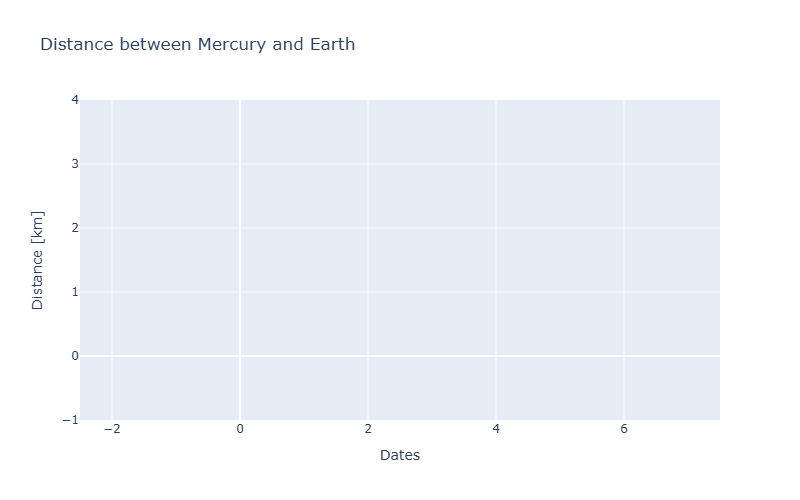

In [9]:
pio.renderers.default = "png"
fig0 = go.Figure()

fig0.update_layout(
    title="Distance between Mercury and Earth",
    xaxis_title="Dates",
    yaxis_title="Distance [km]",
    showlegend=True,
    width=800,
    height=500,
    xaxis=dict(scaleanchor='y', scaleratio=1),
    yaxis=dict(scaleanchor='x', scaleratio=1),
)

Add the distance between the planets over the specified time interval:

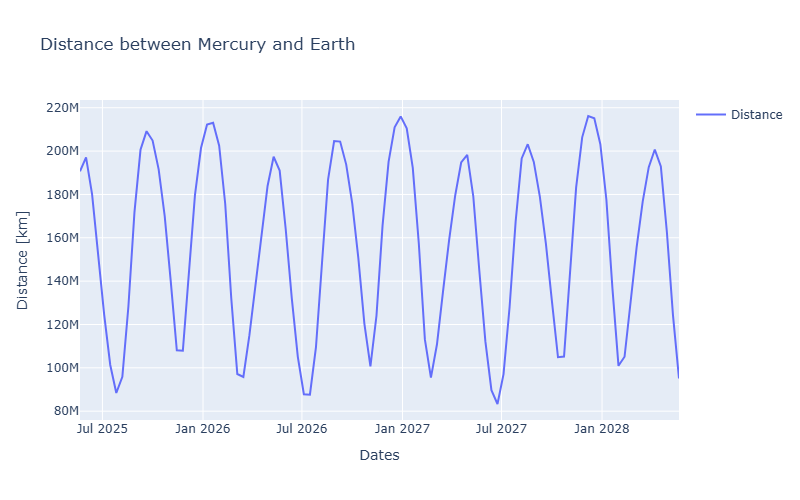

In [10]:
fig0.add_trace(go.Scatter(x=fechas_iso,
                          y=distancia_planetas,
                          name='Distance'))

Finally for this part, find the date on which the distance is minimum. First determine the index where the minimum distance occurs:

In [11]:
min_idx = np.argmin(distancia_planetas)
fecha_min = fechas_iso[min_idx]
distancia_min = distancia_planetas[min_idx]

print(f"Minimum distance {distancia_min:.4f} km is reached on {fecha_min}")

Minimum distance 83308726.9420 km is reached on 2027-06-23 16:54:32.727276


Add this new value to the plot:

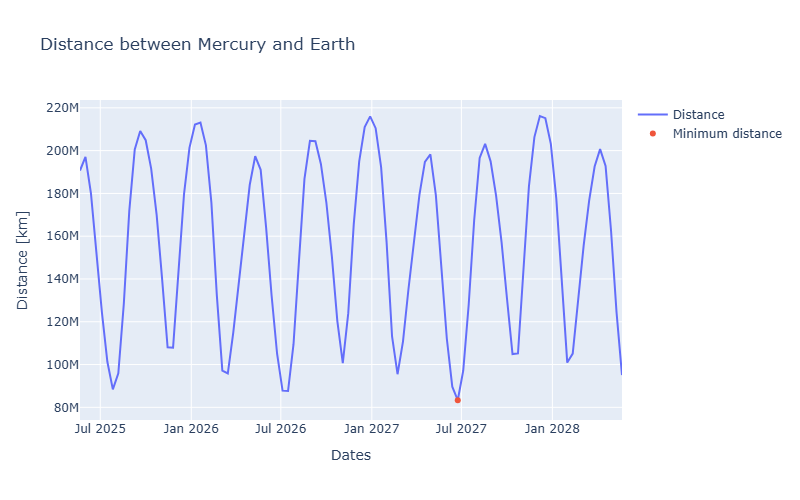

In [12]:
fig0.add_trace(go.Scatter(x=[fecha_min],
                         y=[distancia_min],
                         mode='markers',
                         name='Minimum distance'))

With this, the initial date for searching the launch window can be specified. It corresponds to the date of minimum distance between the planets:

In [13]:
fecha_inicial = fechas_iso[min_idx + 1]

It is also necessary to convert it to Julian time as follows:

In [14]:
tiempo_inicial = Time(fecha_inicial)
fecha_inicial_jd = tiempo_inicial.jd

On the other hand, to determine the minimum flight time:

+ First calculate the semiperimeter:
$$
s = \frac{r_1 + r_2 + c}{2}
$$

In [15]:
r1 = r1_mags[min_idx]
r2 = r2_mags[min_idx]
c = r2 - r1

In [16]:
s = (r1 + r2 + c) / 2

+ It is also necessary to calculate $\mu$:
$$
\mu = G M_\odot
$$

In [17]:
mu = pc.constantes.G * pc.constantes.M_sun

+ Now calculate $t_p$ as follows:

$$
t_p = \frac{\sqrt{2}}{3\sqrt{\mu}} \left[s^{3/2} - (s-c)^{3/2}\right]
$$

In [18]:
t_p1 = ((2 ** 0.5)/ 3) * ((s ** 1.5 - (s - c) ** 1.5) / (mu ** 0.5))

+ Print the result:

In [19]:
print(f"The minimum flight time is: {t_p1/86400:.1f} days")

The minimum flight time is: 19.5 days


In [20]:
t_p2 = ((2 ** 0.5)/ 3) * ((r2 ** 1.5 - (r1) ** 1.5) / mu ** 0.5)

+ To verify the equation:
  $$
  t_p = \frac{\sqrt{2}}{3\sqrt{\mu}} \left|a_p^{3/2} - a_E^{3/2}\right|
  $$

  It is correct to assume that $a_p = r_2$ and $a_E = r_1$, since at that point they approximate circular orbits. Therefore, the equation becomes:

  $$
  t_p = \frac{\sqrt{2}}{3\sqrt{\mu}} \left|r_2^{3/2} - r_1^{3/2}\right|
  $$

In [21]:
t_p2 = ((2 ** 0.5)/ 3) * (np.abs(r2 ** 1.5 - (r1) ** 1.5) / (mu ** 0.5))

In [22]:
print(f"The minimum flight time is: {t_p2/86400:.1f} days")

The minimum flight time is: 19.5 days


+ Therefore, both methods give a minimum flight time of $19.5\thinspace days$.

It is also important to define the different intervals required for this analysis:

+ Search interval for the optimal launch window:

In [23]:
intervalo_busqueda = TimeDelta(200, format='jd')

+ Pivot date:

In [24]:
fecha_pivote = fecha_inicial_jd + intervalo_busqueda

+ Previous interval:

In [25]:
intervalo_previo = TimeDelta(100, format='jd')

+ Subsequent interval:

In [26]:
intervalo_posterior = TimeDelta(250, format='jd')

Finally, use these quantities to define the important dates:

+ Departure dates:

In [27]:
fecha_salida_inicial = fecha_pivote - intervalo_previo

fecha_salida_final = fecha_pivote

+ Arrival dates:

In [28]:
fecha_llegada_inicial = fecha_pivote + t_p2/86400

fecha_llegada_final = fecha_pivote + t_p2/86400 + intervalo_posterior

Create a list between *fecha_salida_inicial* and *fecha_salida_final*:

In [29]:
jds_salida = np.linspace(fecha_salida_inicial.jd,
                         fecha_salida_final.jd, 50)

Do the same for the arrival dates:

In [30]:
jds_llegada = np.linspace(fecha_llegada_inicial.jd,
                         fecha_llegada_final.jd, 50)

Then create a meshgrid from these lists:

In [31]:
TDS, TAS = np.meshgrid(
    Time(jds_salida,format='jd').to_datetime(),
    Time(jds_llegada,format='jd').to_datetime(),
    indexing='ij'
)

TDS.shape, TAS.shape

((50, 50), (50, 50))

+ Define the variable *shape*, which shows the dimensions of the matrices used:

In [32]:
shape = TDS.shape

In [33]:
TDS_jd, TAS_jd = np.meshgrid(jds_salida, jds_llegada, indexing='ij')

With the date list available, the velocities can be determined.

From this, calculate $v_1$ and $v_2$ for the transfer orbit for each date pair:

+ For this, create another `for` loop to query positions and velocities over the specified date range. Also define the matrix where the $C_3$ results will be stored.

Then extract the minimum $C_3$ value.

In [34]:
C3_vals = np.zeros((len(jds_salida), len(jds_llegada)))
vinf_vals = np.zeros((len(jds_salida), len(jds_llegada), 3))

In [36]:
for i, jd_salida in enumerate(jds_salida):
    for j, jd_llegada in enumerate(jds_llegada):
      t_salida = Time(jd_salida, format='jd')
      t_llegada = Time(jd_llegada, format='jd')

      dt_days = (t_llegada - t_salida).value
      dt = dt_days * 86400.0

      tabla, jds, Xs = pc.consulta_horizons(
          id='199',
          location='@0',
          epochs=t_salida.jd)
      r1_vec = Xs[:3]

      v_mercurio= Xs[3:6]

      tabla, jds, Xs = pc.consulta_horizons(
          id='399',
          location='@0',
          epochs=t_llegada.jd)
      r2_vec = Xs[:3]

      v_tierra = Xs[3:6]

      v1, v2, orbita = extra.solucion_lambert(r1_vec, r2_vec, dt, mu=mu)

      vinf = v1 - v_mercurio
      vinf_km = vinf / 1000

      vinf_mag = np.linalg.norm(vinf)
      vinf_mag_km = vinf_mag / 1000

      vinf_vals[i, j] = vinf

      C3_vals[i, j] = vinf_mag_km ** 2

      distancia_km = np.linalg.norm(r2_vec - r1_vec) / 1000
      print(
        f"Departure: {t_salida.iso}, Arrival: {t_llegada.iso}, "
        f"dt: {dt_days:.2f} d, Distance: {distancia_km:.2e} km"
      )

Departure: 2027-10-12 18:32:43.636, Arrival: 2028-02-09 06:52:12.228, dt: 119.51 d, Distance: 1.96e+08 km
Departure: 2027-10-12 18:32:43.636, Arrival: 2028-02-14 09:19:08.555, dt: 124.62 d, Distance: 1.98e+08 km
Departure: 2027-10-12 18:32:43.636, Arrival: 2028-02-19 11:46:04.881, dt: 129.72 d, Distance: 2.00e+08 km
Departure: 2027-10-12 18:32:43.636, Arrival: 2028-02-24 14:13:01.208, dt: 134.82 d, Distance: 2.01e+08 km
Departure: 2027-10-12 18:32:43.636, Arrival: 2028-02-29 16:39:57.534, dt: 139.92 d, Distance: 2.02e+08 km
Departure: 2027-10-12 18:32:43.636, Arrival: 2028-03-05 19:06:53.861, dt: 145.02 d, Distance: 2.03e+08 km
Departure: 2027-10-12 18:32:43.636, Arrival: 2028-03-10 21:33:50.187, dt: 150.13 d, Distance: 2.03e+08 km
Departure: 2027-10-12 18:32:43.636, Arrival: 2028-03-16 00:00:46.514, dt: 155.23 d, Distance: 2.03e+08 km
Departure: 2027-10-12 18:32:43.636, Arrival: 2028-03-21 02:27:42.840, dt: 160.33 d, Distance: 2.03e+08 km
Departure: 2027-10-12 18:32:43.636, Arrival: 2

In [37]:
# prompt: Extract the minimum C3 index
c3_min_idx = np.unravel_index(np.nanargmin(C3_vals), C3_vals.shape)

In [38]:
c3_min = C3_vals[c3_min_idx]

In [39]:
fecha_salida_opt = Time(jds_salida[c3_min_idx[0]], format='jd')
fecha_llegada_opt = Time(jds_llegada[c3_min_idx[1]], format='jd')

In [40]:
vel_esc = c3_min ** 0.5

In [41]:
print(f"The optimal departure date is: {fecha_salida_opt.iso}")
print(f"The optimal arrival date is: {fecha_llegada_opt.iso}")
print(f"Minimum C3 corresponds to {c3_min:.2f} km^2/s^2")
print(f"Escape velocity is: {vel_esc:.2f} km/s")

The optimal departure date is: 2028-01-12 14:37:37.514
The optimal arrival date is: 2028-05-06 00:30:09.779
Minimum C3 corresponds to 70.33 km^2/s^2
Escape velocity is: 8.39 km/s


Using these data, it is possible to plot the porkchop diagram. For easier plot handling, *matplotlib* was used.

+ First, calculate the difference between the dates to create the contours in the plot:

In [42]:
diferencias = np.zeros((len(jds_salida), len(jds_llegada)))

for i, jd_salida in enumerate(jds_salida):
    for j, jd_llegada in enumerate(jds_llegada):
        if jd_llegada > jd_salida:
            diferencias[i, j] = jd_llegada - jd_salida
        else:
            diferencias[i, j] = np.nan


+ Create the figure and add the contours:

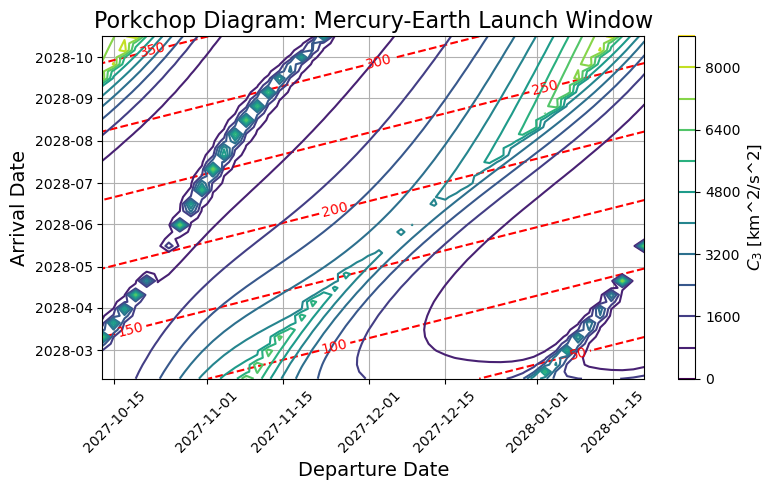

In [43]:
pio.renderers.default = "png"
fig, ax = plt.subplots(figsize=(8, 5))
CS1 = ax.contour(TDS, TAS, diferencias, levels=6, colors='red',
                 linestyles='dashed')
ax.clabel(CS1, inline=True, fontsize=10, fmt='%.0f')
CS2 = ax.contour(TDS, TAS, C3_vals, levels=10, cmap='viridis')
cbar = plt.colorbar(CS2)
cbar.set_label('$C_3$ [km^2/s^2]', fontsize=12)

ax.set_xlabel('Departure Date', fontsize=14)
ax.set_ylabel('Arrival Date', fontsize=14)
ax.set_title('Porkchop Diagram: Mercury-Earth Launch Window',
             fontsize=16)

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In this case, the optimal launch window for the Mercury-to-Earth journey was found. However, the same procedure can be used for the Earth-to-Mercury journey by changing the order in which positions and velocities are queried.